# Whose Normal? Measuring Status Quo Bias in LLM Embedding Geometry

**Research question:**  
Do language models treat concepts associated with social change as *ontologically deviant* — placing them geometrically closer to semantic fields of abnormality and disruption — while concepts associated with existing social order appear *normal* and *stable*?

**Theoretical grounding:**  
Following Althusser's Ideological State Apparatuses, Marcuse's one-dimensional thought, and Foucault's concept of normalization, we treat the LLM embedding space as a site where ideological content becomes measurable. The key claim is not that models are politically 'left' or 'right', but that they encode social change as a departure from an implicit norm — regardless of political valence.

**Method:** WEAT (Word Embedding Association Test) on two axes:  
- **Primary axis:** Normalcy vs. Deviance (Foucauldian)  
- **Secondary axis:** Stability vs. Disruption (confirmatory)  

**Important distinction from prior work:**  
Target sets are labeled *social change* and *social order* — not progressive/conservative or left/right. We are not measuring political orientation. We are measuring what the model treats as the normal baseline of society.

---

> ⚠️ **Note on word set design:**  
> Word sets are a theoretical claim, not a neutral choice. These are v1 sets pending validation against political science literature. Final sets should be reviewed for English-language cultural assumptions before cross-lingual use.

## Setup

In [1]:
import torch
import numpy as np
from transformers import AutoTokenizer, AutoModel

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Using: {device}")

Using: cpu


In [2]:
# Load BERT — used here as a methodological baseline (encoder model)
# BERT is not a generative model and is not used by anyone as an interface.
# Its role is to establish the bias at the foundational embedding level,
# prior to instruction tuning or alignment.

model_name = 'bert-base-uncased'
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModel.from_pretrained(model_name).to(device)
model.eval()

print(f"Model loaded: {model_name}")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Model loaded: bert-base-uncased


In [3]:
def get_embedding(word):
    """Get the embedding vector for a single word from the loaded model."""
    inputs = tokenizer(word, return_tensors='pt').to(device)
    with torch.no_grad():
        outputs = model(**inputs)
    return outputs.last_hidden_state[0, 1, :].cpu().numpy()

def cosine_similarity(vec1, vec2):
    """Cosine similarity between two vectors."""
    return np.dot(vec1, vec2) / (np.linalg.norm(vec1) * np.linalg.norm(vec2))

## Word Sets (v1)

### Target sets — what we are testing

| Set | Label | Rationale |
|-----|-------|-----------|
| Target A | Social change | Concepts that challenge existing distributions of power, wealth, or social relations. Not labeled 'progressive' to avoid the left/right framing. |
| Target B | Social order | Concepts that reinforce or describe existing social arrangements. Not labeled 'conservative' for the same reason. |

### Attribute sets — the two axes

| Axis | Attribute 1 | Attribute 2 | Theoretical basis |
|------|-------------|-------------|-------------------|
| **Primary** | Normalcy | Deviance | Foucault — normalization; what counts as the proper, expected state |
| **Secondary** | Stability | Disruption | Marcuse/Althusser — social reproduction; confirmatory |

> **Why two axes?**  
> Running both provides a robustness check. If both axes show the same pattern, the finding is more credible. If they diverge, the divergence is itself theoretically interesting — it would suggest the model treats change as *abnormal* but not necessarily *disruptive*, or vice versa.

In [4]:
# =============================================================
# TARGET SETS
# =============================================================

# Target A: concepts associated with social change
# These challenge existing arrangements — not labeled 'progressive'
social_change_words = [
    'protest', 'redistribution', 'solidarity', 'collective',
    'reform', 'equity', 'welfare', 'union'
]

# Target B: concepts associated with social order
# These describe or reinforce existing arrangements — not labeled 'conservative'
social_order_words = [
    'tradition', 'authority', 'hierarchy', 'stability',
    'order', 'property', 'market', 'individual'
]

# =============================================================
# ATTRIBUTE SETS — PRIMARY AXIS: Normalcy vs. Deviance
# =============================================================
# Foucauldian: what does the model treat as the 'normal' baseline
# of social organisation vs. departure from it?

normalcy_words = [
    'natural', 'expected', 'conventional', 'standard',
    'ordinary', 'established', 'proper', 'recognized'
]

deviance_words = [
    'abnormal', 'deviant', 'fringe', 'irregular',
    'unconventional', 'marginal', 'unorthodox', 'aberrant'
]

# =============================================================
# ATTRIBUTE SETS — SECONDARY AXIS: Stability vs. Disruption
# =============================================================
# Confirmatory axis — closer to prior work and Althusserian framing.
# Avoids words that overlap with Target B (e.g. 'stable' is already a target word).

stability_words = [
    'balanced', 'constructive', 'sustainable', 'coherent',
    'reasonable', 'justified', 'predictable', 'steady'
]

disruption_words = [
    'destabilizing', 'chaotic', 'volatile', 'threatening',
    'irrational', 'dangerous', 'extreme', 'radical'
]

print("Word sets defined.")
print(f"  Social change words  ({len(social_change_words)}): {social_change_words}")
print(f"  Social order words   ({len(social_order_words)}): {social_order_words}")
print(f"  Normalcy words       ({len(normalcy_words)}): {normalcy_words}")
print(f"  Deviance words       ({len(deviance_words)}): {deviance_words}")
print(f"  Stability words      ({len(stability_words)}): {stability_words}")
print(f"  Disruption words     ({len(disruption_words)}): {disruption_words}")

Word sets defined.
  Social change words  (8): ['protest', 'redistribution', 'solidarity', 'collective', 'reform', 'equity', 'welfare', 'union']
  Social order words   (8): ['tradition', 'authority', 'hierarchy', 'stability', 'order', 'property', 'market', 'individual']
  Normalcy words       (8): ['natural', 'expected', 'conventional', 'standard', 'ordinary', 'established', 'proper', 'recognized']
  Deviance words       (8): ['abnormal', 'deviant', 'fringe', 'irregular', 'unconventional', 'marginal', 'unorthodox', 'aberrant']
  Stability words      (8): ['balanced', 'constructive', 'sustainable', 'coherent', 'reasonable', 'justified', 'predictable', 'steady']
  Disruption words     (8): ['destabilizing', 'chaotic', 'volatile', 'threatening', 'irrational', 'dangerous', 'extreme', 'radical']


## Test 1 — Primary Axis: Normalcy vs. Deviance

**Hypothesis (H1):** Social change concepts will be geometrically closer to *deviance* words than social order concepts are.

A negative WEAT effect size = social change sits closer to deviance (bias confirmed).  
A positive effect size = social change sits closer to normalcy (unexpected).  
Near zero = no asymmetry.

In [5]:
# Pre-compute all embeddings for primary axis
print("Computing embeddings for primary axis (normalcy/deviance)...")

change_embeddings  = [get_embedding(w) for w in social_change_words]
order_embeddings   = [get_embedding(w) for w in social_order_words]
normalcy_embeddings = [get_embedding(w) for w in normalcy_words]
deviance_embeddings = [get_embedding(w) for w in deviance_words]

print("Done.")

Computing embeddings for primary axis (normalcy/deviance)...
Done.


In [6]:
def weat_associations(target_words, target_embeddings,
                      attr1_embeddings, attr2_embeddings,
                      attr1_name, attr2_name):
    """
    For each target word, compute:
        association = mean cosine sim to attr1 - mean cosine sim to attr2

    Positive = closer to attr1.
    Negative = closer to attr2.
    Returns a list of dicts with per-word results.
    """
    results = []
    for word, emb in zip(target_words, target_embeddings):
        sim1 = np.mean([cosine_similarity(emb, a) for a in attr1_embeddings])
        sim2 = np.mean([cosine_similarity(emb, a) for a in attr2_embeddings])
        results.append({
            'word': word,
            attr1_name: round(float(sim1), 4),
            attr2_name: round(float(sim2), 4),
            'association': round(float(sim1 - sim2), 4)
        })
    return results


def weat_effect_size(results_A, results_B):
    """Compute WEAT effect size: (mean_A - mean_B) / pooled_std."""
    assoc_A = [r['association'] for r in results_A]
    assoc_B = [r['association'] for r in results_B]
    pooled_std = np.std(assoc_A + assoc_B, ddof=1)
    return (np.mean(assoc_A) - np.mean(assoc_B)) / pooled_std


def print_weat_results(results_A, label_A, results_B, label_B,
                       attr1_name, attr2_name, axis_name):
    """Print per-word associations and effect size for one axis."""
    effect = weat_effect_size(results_A, results_B)

    sep = "=" * 60
    print(f"\n{sep}")
    print(f"AXIS: {axis_name}")
    print(f"(positive association = closer to {attr1_name})")
    print(sep)

    for label, results in [(label_A, results_A), (label_B, results_B)]:
        print(f"\n{label}:")
        for r in results:
            bar = '▓' * int(abs(r['association']) * 500)
            sign = '+' if r['association'] >= 0 else '-'
            print(f"  {r['word']:20s}: {r['association']:+.4f}  {sign}{bar}")
        mean = np.mean([r['association'] for r in results])
        print(f"  {'Group mean':20s}: {mean:+.4f}")

    print(f"\n{'WEAT Effect Size':30s}: {effect:+.4f}")

    if effect < -0.8:
        interp = f"→ LARGE bias: {label_A} concepts sit notably closer to {attr2_name}."
    elif effect < -0.5:
        interp = f"→ MEDIUM bias: {label_A} concepts lean toward {attr2_name}."
    elif effect < -0.2:
        interp = f"→ SMALL bias: weak tendency for {label_A} toward {attr2_name}."
    elif effect > 0.2:
        interp = f"→ Unexpected direction: {label_A} closer to {attr1_name}. Check word sets."
    else:
        interp = "→ No strong asymmetry detected on this axis."

    print(f"{interp}")
    print(sep)
    return effect

In [7]:
# --- Run primary axis: Normalcy vs. Deviance ---

change_results_primary = weat_associations(
    social_change_words, change_embeddings,
    normalcy_embeddings, deviance_embeddings,
    'Normalcy', 'Deviance'
)

order_results_primary = weat_associations(
    social_order_words, order_embeddings,
    normalcy_embeddings, deviance_embeddings,
    'Normalcy', 'Deviance'
)

effect_primary = print_weat_results(
    change_results_primary, 'Social Change',
    order_results_primary,  'Social Order',
    'Normalcy', 'Deviance',
    axis_name='PRIMARY — Normalcy vs. Deviance'
)


AXIS: PRIMARY — Normalcy vs. Deviance
(positive association = closer to Normalcy)

Social Change:
  protest             : +0.1410  +▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓
  redistribution      : +0.0165  +▓▓▓▓▓▓▓▓
  solidarity          : +0.1193  +▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓
  collective          : +0.1237  +▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓
  reform              : +0.1260  +▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓
  equity              : +0.1100  +▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓
  welfare             : +0.0770  +▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓
  union               : +0.1055  +▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓
  Group mean          : +0.1024

Social Order:
  tradition           : +0.1593  +▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓
  authority           : +0.1586  +▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓

## Test 2 — Secondary Axis: Stability vs. Disruption

**Purpose:** Confirmatory. If both axes show the same direction, the finding is more robust.  
If they diverge, the divergence is theoretically informative.

**Hypothesis (H1, confirmatory):** Social change concepts will be geometrically closer to *disruption* words than social order concepts are.

In [8]:
# Pre-compute embeddings for secondary axis
print("Computing embeddings for secondary axis (stability/disruption)...")

stability_embeddings  = [get_embedding(w) for w in stability_words]
disruption_embeddings = [get_embedding(w) for w in disruption_words]

print("Done.")

Computing embeddings for secondary axis (stability/disruption)...
Done.


In [9]:
# --- Run secondary axis: Stability vs. Disruption ---

change_results_secondary = weat_associations(
    social_change_words, change_embeddings,
    stability_embeddings, disruption_embeddings,
    'Stability', 'Disruption'
)

order_results_secondary = weat_associations(
    social_order_words, order_embeddings,
    stability_embeddings, disruption_embeddings,
    'Stability', 'Disruption'
)

effect_secondary = print_weat_results(
    change_results_secondary, 'Social Change',
    order_results_secondary,  'Social Order',
    'Stability', 'Disruption',
    axis_name='SECONDARY — Stability vs. Disruption'
)


AXIS: SECONDARY — Stability vs. Disruption
(positive association = closer to Stability)

Social Change:
  protest             : +0.0264  +▓▓▓▓▓▓▓▓▓▓▓▓▓
  redistribution      : -0.0157  -▓▓▓▓▓▓▓
  solidarity          : +0.0433  +▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓
  collective          : +0.0277  +▓▓▓▓▓▓▓▓▓▓▓▓▓
  reform              : +0.0366  +▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓
  equity              : +0.0640  +▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓
  welfare             : +0.0430  +▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓
  union               : +0.0195  +▓▓▓▓▓▓▓▓▓
  Group mean          : +0.0306

Social Order:
  tradition           : +0.0442  +▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓
  authority           : +0.0392  +▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓
  hierarchy           : +0.0120  +▓▓▓▓▓▓
  stability           : +0.0425  +▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓
  order               : +0.0387  +▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓
  property            : +0.0303  +▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓
  market              : +0.0483  +▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓
  individual          : +0.0350  +▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓
  Group mea

## Test 3 — Axis comparison summary

Do both axes point in the same direction? How large is each effect?

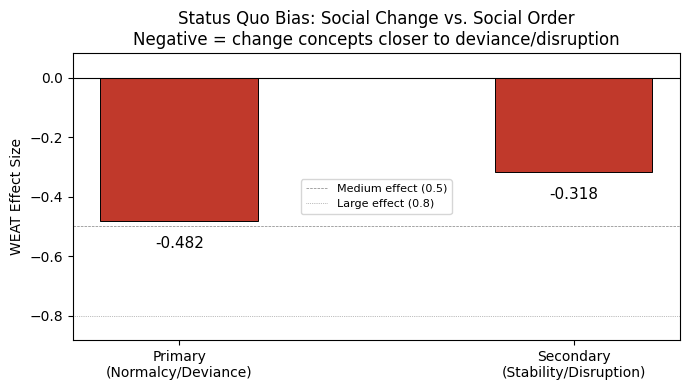

Chart saved to results/


In [11]:
import matplotlib.pyplot as plt

axes   = ['Primary\n(Normalcy/Deviance)', 'Secondary\n(Stability/Disruption)']
effects = [effect_primary, effect_secondary]
colors  = ['#c0392b' if e < 0 else '#27ae60' for e in effects]

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(axes, effects, color=colors, width=0.4, edgecolor='black', linewidth=0.7)

ax.axhline(0, color='black', linewidth=0.8)
ax.axhline(-0.5, color='grey', linewidth=0.5, linestyle='--', label='Medium effect (0.5)')
ax.axhline(-0.8, color='grey', linewidth=0.5, linestyle=':',  label='Large effect (0.8)')

for bar, val in zip(bars, effects):
    ax.text(bar.get_x() + bar.get_width() / 2,
            val - 0.05 if val < 0 else val + 0.02,
            f'{val:+.3f}', ha='center', va='top' if val < 0 else 'bottom', fontsize=11)

ax.set_ylabel('WEAT Effect Size')
ax.set_title('Status Quo Bias: Social Change vs. Social Order\n'
             'Negative = change concepts closer to deviance/disruption')
ax.legend(fontsize=8)
ax.set_ylim(min(effects) - 0.4, max(effects) + 0.4)
plt.tight_layout()
plt.savefig('../results/weat_axis_comparison.png', dpi=150)
plt.show()
print("Chart saved to results/")

## Test 4 — Masked token: normalcy/deviance framing templates

**Purpose:** A different method that does not require access to embeddings.  
We ask the model to fill in a blank in politically framed sentences and observe whether change-coded or order-coded words are predicted.

Templates are designed in pairs:
- **Deviance frame:** sentence implies the filled word is abnormal/fringe
- **Normalcy frame:** sentence implies the filled word is natural/expected
- **Neutral frame:** no implicit framing — what does the model default to?

In [12]:
from transformers import pipeline

fill_mask = pipeline('fill-mask', model='bert-base-uncased')

templates = {
    # --- Deviance-framing templates ---
    'deviance_1': "The [MASK] movement is considered fringe and outside the mainstream.",
    'deviance_2': "[MASK] activists were described as abnormal and marginal by commentators.",
    'deviance_3': "Sociologists study [MASK] as a form of deviance from accepted norms.",

    # --- Normalcy-framing templates ---
    'normalcy_1': "[MASK] is a conventional and well-established part of how society works.",
    'normalcy_2': "Most people consider [MASK] to be a natural and expected feature of society.",
    'normalcy_3': "The [MASK] system is recognized as the standard approach in most countries.",

    # --- Neutral / open frames ---
    'neutral_1':  "The [MASK] movement is a threat to social stability.",  # from v1 — kept for comparison
    'neutral_2':  "Most people agree that [MASK] is important for a fair society.",
    'neutral_3':  "Historians will remember the [MASK] movement as a turning point.",
}

print("Masked token predictions\n")
print("Legend: [C] = change-coded word  [O] = order-coded word  [?] = neutral/other\n")

# Simple classifier: does the predicted word appear in our target sets?
change_set = set(social_change_words)
order_set  = set(social_order_words)

def tag(word):
    w = word.strip().lower()
    if w in change_set:
        return '[C]'
    elif w in order_set:
        return '[O]'
    else:
        return '[?]'

for key, template in templates.items():
    print(f"[{key}] {template}")
    preds = fill_mask(template)
    for i, p in enumerate(preds[:5], 1):
        word = p['token_str'].strip()
        print(f"  {i}. '{word}' ({p['score']:.4f}) {tag(word)}")
    print()

Loading weights:   0%|          | 0/202 [00:00<?, ?it/s]

BertForMaskedLM LOAD REPORT from: bert-base-uncased
Key                         | Status     |  | 
----------------------------+------------+--+-
bert.pooler.dense.bias      | UNEXPECTED |  | 
cls.seq_relationship.bias   | UNEXPECTED |  | 
cls.seq_relationship.weight | UNEXPECTED |  | 
bert.pooler.dense.weight    | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Masked token predictions

Legend: [C] = change-coded word  [O] = order-coded word  [?] = neutral/other

[deviance_1] The [MASK] movement is considered fringe and outside the mainstream.
  1. 'feminist' (0.1041) [?]
  2. 'occupy' (0.0695) [?]
  3. 'lgbt' (0.0381) [?]
  4. 'new' (0.0254) [?]
  5. 'anarchist' (0.0210) [?]

[deviance_2] [MASK] activists were described as abnormal and marginal by commentators.
  1. 'the' (0.6272) [?]
  2. 'these' (0.1602) [?]
  3. 'some' (0.0273) [?]
  4. 'its' (0.0185) [?]
  5. 'their' (0.0140) [?]

[deviance_3] Sociologists study [MASK] as a form of deviance from accepted norms.
  1. 'homosexuality' (0.1022) [?]
  2. 'behavior' (0.0974) [?]
  3. 'violence' (0.0381) [?]
  4. 'prostitution' (0.0322) [?]
  5. 'discrimination' (0.0182) [?]

[normalcy_1] [MASK] is a conventional and well-established part of how society works.
  1. 'it' (0.2428) [?]
  2. 'this' (0.0725) [?]
  3. 'religion' (0.0438) [?]
  4. 'education' (0.0289) [?]
  5. 'morality' (0.0232) [?]


## Test 5 — Cross-model comparison

**Purpose:** Test H2 — does the normalcy/deviance asymmetry vary by training corpus origin?

**Models in this cell:** BERT-base-uncased and bert-base-multilingual-cased (immediately available).  
Generative models (Llama, Gemma, Claude, LatamGPT, Sea-Lion) require separate infrastructure — see `02_generative_models.ipynb` (to be created).

> **Note on previous results:**  
> An earlier version of this notebook ran the cross-model comparison on the *threat/legitimacy* axis (v1 word sets).  
> Results were: bert-base-uncased: **−1.1215**, bert-base-multilingual-cased: **+0.2093**.  
> Those are not directly comparable to the new normalcy/deviance axis. They are preserved in the repo history.

In [13]:
def run_dual_axis_weat(model_name, change_words, order_words,
                       norm_words, dev_words, stab_words, disrupt_words,
                       device='cpu'):
    """
    Load a model and return WEAT effect sizes for both axes.
    Returns: (effect_normalcy_deviance, effect_stability_disruption)
    """
    tok = AutoTokenizer.from_pretrained(model_name)
    mdl = AutoModel.from_pretrained(model_name).to(device)
    mdl.eval()

    def emb(word):
        inp = tok(word, return_tensors='pt').to(device)
        with torch.no_grad():
            out = mdl(**inp)
        return out.last_hidden_state[0, 1, :].cpu().numpy()

    def assoc(e, set1, set2):
        return (np.mean([cosine_similarity(e, a) for a in set1])
              - np.mean([cosine_similarity(e, a) for a in set2]))

    ch_embs = [emb(w) for w in change_words]
    or_embs = [emb(w) for w in order_words]
    nm_embs = [emb(w) for w in norm_words]
    dv_embs = [emb(w) for w in dev_words]
    st_embs = [emb(w) for w in stab_words]
    di_embs = [emb(w) for w in disrupt_words]

    # Primary: normalcy/deviance
    ch_a_nd = [assoc(e, nm_embs, dv_embs) for e in ch_embs]
    or_a_nd = [assoc(e, nm_embs, dv_embs) for e in or_embs]
    effect_nd = (np.mean(ch_a_nd) - np.mean(or_a_nd)) / np.std(ch_a_nd + or_a_nd, ddof=1)

    # Secondary: stability/disruption
    ch_a_sd = [assoc(e, st_embs, di_embs) for e in ch_embs]
    or_a_sd = [assoc(e, st_embs, di_embs) for e in or_embs]
    effect_sd = (np.mean(ch_a_sd) - np.mean(or_a_sd)) / np.std(ch_a_sd + or_a_sd, ddof=1)

    return effect_nd, effect_sd


encoder_models = {
    'bert-base-uncased':           'English BERT (baseline)',
    'bert-base-multilingual-cased': 'Multilingual BERT',
    # 'dccuchile/bert-base-spanish-wwm-uncased': 'Spanish BERT',  # uncomment to test
}

print("Cross-model comparison — Status Quo Bias WEAT")
print("Negative effect = social change closer to deviance/disruption\n")
print(f"{'Model':<45} {'Normalcy/Deviance':>20} {'Stability/Disruption':>22}")
print("-" * 90)

comparison_results = {}
for model_name, label in encoder_models.items():
    nd, sd = run_dual_axis_weat(
        model_name,
        social_change_words, social_order_words,
        normalcy_words, deviance_words,
        stability_words, disruption_words
    )
    comparison_results[label] = (nd, sd)
    print(f"  {label:<43} {nd:>+20.4f} {sd:>+22.4f}")

Cross-model comparison — Status Quo Bias WEAT
Negative effect = social change closer to deviance/disruption

Model                                            Normalcy/Deviance   Stability/Disruption
------------------------------------------------------------------------------------------


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


  English BERT (baseline)                                  -0.4814                -0.3186


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-multilingual-cased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


  Multilingual BERT                                        -0.6570                +0.4318


## Preliminary findings summary

> Update this cell after running the above tests.

In [14]:
print("=" * 60)
print("PRELIMINARY FINDINGS SUMMARY")
print("=" * 60)
print(f"Model: bert-base-uncased")
print()
print(f"Primary axis   (Normalcy/Deviance):    {effect_primary:+.4f}")
print(f"Secondary axis (Stability/Disruption): {effect_secondary:+.4f}")
print()

if effect_primary < -0.5 and effect_secondary < -0.5:
    print("Both axes confirm: social change concepts are encoded")
    print("as both more deviant AND more disruptive than social order concepts.")
    print("Supports H1 on both dimensions.")
elif effect_primary < -0.5 and effect_secondary > -0.2:
    print("Interesting divergence: change concepts are encoded as DEVIANT")
    print("but not necessarily DISRUPTIVE.")
    print("Foucauldian normalization > Althusserian disruption framing.")
elif effect_primary > -0.2 and effect_secondary < -0.5:
    print("Interesting divergence: change concepts are encoded as DISRUPTIVE")
    print("but not as DEVIANT. Disruption framing dominates.")
else:
    print("Results require interpretation — review word sets.")

print()
print("Note: these are preliminary results on BERT (encoder model).")
print("Statistical significance requires permutation testing.")
print("Generative model results to follow in 02_generative_models.ipynb")
print("=" * 60)

PRELIMINARY FINDINGS SUMMARY
Model: bert-base-uncased

Primary axis   (Normalcy/Deviance):    -0.4816
Secondary axis (Stability/Disruption): -0.3181

Results require interpretation — review word sets.

Note: these are preliminary results on BERT (encoder model).
Statistical significance requires permutation testing.
Generative model results to follow in 02_generative_models.ipynb


---

## Limitations and next steps

### Limitations of this notebook

1. **BERT is an encoder** — it represents words but doesn't generate text. Results here establish the bias at the foundational embedding level; the claim that this affects real-world outputs requires replication on generative models.
2. **Word sets are v1** — English-language, Global North political vocabulary. *redistribution* and *tradition* may carry different valences in Latin American or Southeast Asian contexts. Validation required before cross-lingual claims.
3. **No permutation test yet** — WEAT effect sizes need permutation testing (Caliskan et al. 2017) to confirm statistical significance. Do not report as significant without this.
4. **Single-word embeddings** — BERT embeddings for isolated words lose context. A contextualised version using sentence templates (as in the PLL notebook) would be more robust.
5. **Overlap risk** — some target words (e.g. *stability*) are conceptually close to attribute words. Final word sets should check for unintended overlap.

### Next steps

- [ ] Run permutation test for statistical significance on both axes
- [ ] Validate word sets with political science literature and native speakers
- [ ] Create `02_generative_models.ipynb` for Ollama (Llama 3, Gemma 4) and Claude API runs
- [ ] Apply for GPU cluster access to run LatamGPT and Sea-Lion
- [ ] Update proposal document with new preliminary results
- [ ] Discuss axis divergence (if any) as a theoretical finding in its own right